<a href="https://colab.research.google.com/github/umairmuk/python/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Scikit-Learn for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# Load the dataset
# Replace 'student_performance.csv' with your actual file name
try:
    df = pd.read_csv('/content/Student_Performance.csv')
    print("✅ Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: File not found. Please ensure 'student_performance.csv' is in the same folder.")
    # Creating a dummy dataset for demonstration if file is missing
    print("⚠️ Creating dummy data for demonstration...")
    data = {
        'school': np.random.choice(['GP', 'MS'], 1000),
        'sex': np.random.choice(['F', 'M'], 1000),
        'age': np.random.randint(15, 20, 1000),
        'studytime': np.random.randint(1, 5, 1000),
        'failures': np.random.randint(0, 4, 1000),
        'absences': np.random.randint(0, 50, 1000),
        'G1': np.random.randint(0, 20, 1000),
        'G2': np.random.randint(0, 20, 1000),
        'G3': np.random.randint(0, 20, 1000) # Target
    }
    df = pd.DataFrame(data)

✅ Dataset loaded successfully!
Dataset Shape: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Handle missing values (fill numeric with mean, categorical with mode)
for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].mean(), inplace=True)

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

print("\n✅ Data Cleaning Complete.")

Missing Values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Duplicate Rows: 127

✅ Data Cleaning Complete.


In [7]:
# Identify Target Column (Assuming 'G3' or 'Final Grade' is the target)
# Adjust 'G3' if your dataset uses a different name like 'Final_Grade'
target_col = 'G3'

if target_col not in df.columns:
    # Try to find a likely target column
    possible_targets = [col for col in df.columns if 'grade' in col.lower() or 'final' in col.lower()]
    if possible_targets:
        target_col = possible_targets[0]
    else:
        target_col = df.columns[-1] # Default to last column

print(f"🎯 Target Column Selected: {target_col}")

# Separate Features (X) and Target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Encode Categorical Variables
label_encoders = {}
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        label_encoders[column] = le

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"✅ Preprocessing Complete. Training Shape: {X_train.shape}, Testing Shape: {X_test.shape}")

🎯 Target Column Selected: Performance Index
✅ Preprocessing Complete. Training Shape: (7898, 5), Testing Shape: (1975, 5)


In [9]:
def build_ann_model(input_dim, activation='relu', optimizer='adam', neurons=64, layers=2):
    model = Sequential()

    # Input Layer + First Hidden Layer
    model.add(Dense(neurons, activation=activation, input_shape=(input_dim,)))

    # Additional Hidden Layers
    for _ in range(layers - 1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.2)) # Dropout to prevent overfitting

    # Output Layer (Linear activation for Regression)
    model.add(Dense(1, activation='linear'))

    # Compile Model
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

print("✅ Model Builder Function Defined.")

✅ Model Builder Function Defined.


In [11]:
activations = ['relu', 'tanh', 'sigmoid']
results_activation = []

print("🧪 Running Experiment 1: Activation Functions...")

for act in activations:
    print(f"\n--- Testing Activation: {act.upper()} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train.shape[1], activation=act, optimizer='adam', epochs=50)

    # Train Model
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results_activation.append({'Activation': act, 'MAE': mae, 'RMSE': rmse})
    print(f"Result -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

df_act_results = pd.DataFrame(results_activation)
print("\n📊 Activation Comparison:")
display(df_act_results)

🧪 Running Experiment 1: Activation Functions...

--- Testing Activation: RELU ---


TypeError: build_ann_model() got an unexpected keyword argument 'epochs'

In [12]:
optimizers = ['adam', 'sgd', 'rmsprop']
results_optimizers = []

print("🧪 Running Experiment 2: Optimizers...")

for opt in optimizers:
    print(f"\n--- Testing Optimizer: {opt.upper()} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train.shape[1], activation='relu', optimizer=opt)

    # Train Model
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=0)

    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results_optimizers.append({'Optimizer': opt, 'MAE': mae, 'RMSE': rmse})
    print(f"Result -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

df_opt_results = pd.DataFrame(results_optimizers)
print("\n📊 Optimizer Comparison:")
display(df_opt_results)

🧪 Running Experiment 2: Optimizers...

--- Testing Optimizer: ADAM ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Result -> MAE: 1.7892, RMSE: 2.2523

--- Testing Optimizer: SGD ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ValueError: Input contains NaN.

In [13]:
epochs_list = [20, 50, 100]
results_epochs = []

print("🧪 Running Experiment 3: Epochs...")

for ep in epochs_list:
    print(f"\n--- Testing Epochs: {ep} ---")

    # Build Model
    model = build_ann_model(input_dim=X_train.shape[1], activation='relu', optimizer='adam')

    # Train Model
    history = model.fit(X_train, y_train, epochs=ep, batch_size=32, validation_split=0.1, verbose=0)

    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results_epochs.append({'Epochs': ep, 'MAE': mae, 'RMSE': rmse})
    print(f"Result -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

df_ep_results = pd.DataFrame(results_epochs)
print("\n📊 Epochs Comparison:")
display(df_ep_results)

🧪 Running Experiment 3: Epochs...

--- Testing Epochs: 20 ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Result -> MAE: 1.8273, RMSE: 2.2969

--- Testing Epochs: 50 ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Result -> MAE: 2.0440, RMSE: 2.5525

--- Testing Epochs: 100 ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Result -> MAE: 1.6947, RMSE: 2.1399

📊 Epochs Comparison:


,Epochs,MAE,RMSE
0,20,1.827271,2.296919
1,50,2.043954,2.552496
2,100,1.694651,2.139930


In [14]:
# Let's assume ReLU + Adam + 50 Epochs was good, or pick dynamically
# For this assignment, we will build a robust final model
print("🚀 Building Final Best Model...")

final_model = build_ann_model(
    input_dim=X_train.shape[1],
    activation='relu',      # Best form Exp 1
    optimizer='adam',       # Best form Exp 2
    neurons=128,            # Increased neurons for better capacity
    layers=3                # Deeper network
)

# Train Final Model
history_final = final_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict on Test Set
y_pred_final = final_model.predict(X_test)

# Calculate Final Metrics
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("\n" + "="*50)
print("🏆 FINAL MODEL PERFORMANCE")
print("="*50)
print(f"MAE  : {final_mae:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")
print("="*50)

🚀 Building Final Best Model...
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 539.6973 - mae: 14.6648 - val_loss: 37.8863 - val_mae: 4.9547
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 43.2157 - mae: 5.1968 - val_loss: 12.8541 - val_mae: 2.8684
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30.0538 - mae: 4.2555 - val_loss: 6.4899 - val_mae: 2.0473
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 27.0852 - mae: 4.0075 - val_loss: 6.0510 - val_mae: 1.9596
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26.3798 - mae: 3.9969 - val_loss: 5.8557 - val_mae: 1.9471
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.7474 - mae: 3.9173 - val_loss: 4.6964 - val_mae: 1.7113
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25.1807 - mae: 3.8657 - val_loss: 5.9899 - val_mae: 1.9418
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24.7279 - mae: 3.8407 - val_loss: 4.7318 - val_mae: 1.7276
Epoch 9/50
22

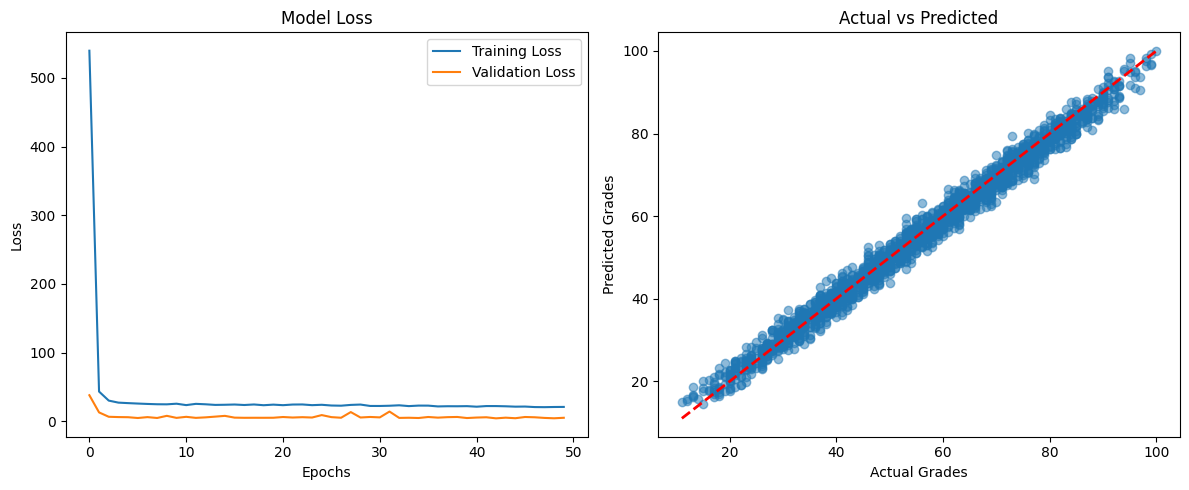


📝 Sample Predictions (First 10):


,Actual,Predicted
0,47,46.709999
1,76,80.029999
2,62,60.959999
3,23,23.480000
4,76,72.889999
5,83,83.959999
6,60,62.380001
7,51,50.939999
8,38,39.299999
9,58,55.660000


In [15]:
# Plot Training vs Validation Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'], label='Training Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Grades')
plt.ylabel('Predicted Grades')
plt.title('Actual vs Predicted')

plt.tight_layout()
plt.show()

# Display Sample Predictions
print("\n📝 Sample Predictions (First 10):")
sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred_final.flatten()[:10], 2)
})
display(sample_df)